# 01. Synthetic Control for a Marketing Pilot

This notebook is a self-contained introduction to synthetic control methods using a marketing example.

It follows the spirit of Abadie, Diamond, and Hainmueller's California tobacco paper:
- one aggregate unit is exposed to a policy or intervention,
- a donor pool remains untreated,
- the counterfactual for the treated unit is a weighted combination of donor units, and
- the credibility of the design comes from pre-treatment fit, predictor balance, and placebo comparisons.

Here, the treated unit is a single retail market that launches a large loyalty-app pilot.

## Learning Goals

By the end of this notebook, you should be able to:
- Explain when synthetic control is appropriate.
- Define the source of the shock and the donor pool.
- State the identification assumptions behind synthetic control.
- Check whether the treated market looks similar to its synthetic control before treatment.
- Estimate and interpret the post-treatment gap.
- Use placebo tests to assess whether the treated gap is unusually large.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import StrMethodFormatter

plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False
pd.set_option("display.float_format", lambda value: f"{value:,.3f}")
rng = np.random.default_rng(2027)

## Marketing Setup And Source Of The Shock

Suppose a retailer launches a high-touch loyalty-app pilot in **Phoenix** beginning in month 19. The pilot bundles app-exclusive offers, richer push notifications, and faster local fulfillment messaging.

Why only Phoenix?
- Phoenix is the first market where the app vendor completed point-of-sale integration.
- Local store managers and the fulfillment partner were ready there earlier than in other markets.
- Other markets remain untreated during the sample window.

That makes the intervention a market-level shock beginning at a clearly defined date. Synthetic control is useful here because there is only one treated aggregate unit and many untreated comparison markets.

In [2]:
months = np.arange(1, 25)
treatment_start = 19
treated_market = "Phoenix"
donor_markets = [
    "Austin",
    "Charlotte",
    "Columbus",
    "Denver",
    "Indianapolis",
    "KansasCity",
    "Nashville",
    "Orlando",
    "Portland",
    "Sacramento",
    "SaltLake",
    "Tampa",
]

market_chars = pd.DataFrame({
    "market_id": donor_markets,
    "population_index": rng.normal(100, 10, len(donor_markets)),
    "digital_share": np.clip(rng.normal(0.42, 0.05, len(donor_markets)), 0.25, 0.65),
    "prior_roas": rng.normal(4.1, 0.35, len(donor_markets)),
    "intercept": rng.normal(0, 4, len(donor_markets)),
    "trend_loading": rng.normal(1.0, 0.10, len(donor_markets)),
    "season_loading": rng.normal(1.0, 0.08, len(donor_markets)),
})

common_trend = np.linspace(-8, 14, len(months))
seasonality = 5 * np.sin(2 * np.pi * months / 12)

donor_outcomes = {}
for row in market_chars.itertuples(index=False):
    baseline = 175 + 0.70 * row.population_index + 45 * row.digital_share + 8 * row.prior_roas + row.intercept
    market_series = (
        baseline
        + row.trend_loading * common_trend
        + row.season_loading * seasonality
        + rng.normal(0, 2.5, len(months))
    )
    donor_outcomes[row.market_id] = market_series

donor_outcome_wide = pd.DataFrame(donor_outcomes, index=months)

true_weights = pd.Series(0.0, index=donor_markets)
true_weights.loc[["Denver", "Nashville", "Sacramento", "Tampa"]] = [0.35, 0.30, 0.20, 0.15]

treated_market_chars = pd.Series({
    "population_index": market_chars.set_index("market_id")["population_index"].dot(true_weights) + rng.normal(0, 1),
    "digital_share": market_chars.set_index("market_id")["digital_share"].dot(true_weights) + rng.normal(0, 0.004),
    "prior_roas": market_chars.set_index("market_id")["prior_roas"].dot(true_weights) + rng.normal(0, 0.04),
})

untreated_phoenix = donor_outcome_wide.dot(true_weights) + rng.normal(0, 1.2, len(months))
marketing_shock = np.array([0] * (treatment_start - 1) + [6, 8, 11, 13, 15, 16])
treated_outcome = untreated_phoenix + marketing_shock

market_level = pd.concat(
    [
        market_chars[["market_id", "population_index", "digital_share", "prior_roas"]],
        pd.DataFrame(
            {
                "market_id": [treated_market],
                "population_index": [treated_market_chars["population_index"]],
                "digital_share": [treated_market_chars["digital_share"]],
                "prior_roas": [treated_market_chars["prior_roas"]],
            }
        ),
    ],
    ignore_index=True,
)

panel_rows = []
for donor_market in donor_markets:
    chars = market_level.loc[market_level["market_id"] == donor_market].iloc[0]
    for month in months:
        panel_rows.append(
            {
                "market_id": donor_market,
                "month": month,
                "orders": donor_outcome_wide.loc[month, donor_market],
                "population_index": chars["population_index"],
                "digital_share": chars["digital_share"],
                "prior_roas": chars["prior_roas"],
                "treated_market": 0,
            }
        )

phoenix_chars = market_level.loc[market_level["market_id"] == treated_market].iloc[0]
for month in months:
    panel_rows.append(
        {
            "market_id": treated_market,
            "month": month,
            "orders": treated_outcome.loc[month],
            "population_index": phoenix_chars["population_index"],
            "digital_share": phoenix_chars["digital_share"],
            "prior_roas": phoenix_chars["prior_roas"],
            "treated_market": 1,
        }
    )

panel = pd.DataFrame(panel_rows)
panel.head()

,market_id,month,orders,population_index,digital_share,prior_roas,treated_market
0,Austin,1,283.409,101.109,0.407,4.052,0
1,Austin,2,286.947,101.109,0.407,4.052,0
2,Austin,3,288.981,101.109,0.407,4.052,0
3,Austin,4,292.594,101.109,0.407,4.052,0
4,Austin,5,287.572,101.109,0.407,4.052,0


## Identification Assumptions

The identifying logic of synthetic control is different from standard DiD, but it still requires strong design assumptions:
- **No spillovers:** the Phoenix pilot does not change outcomes in donor markets.
- **No other Phoenix-only shock at month 19:** nothing else turns on in Phoenix at the same time.
- **Good pre-treatment fit:** a weighted combination of donor markets can reproduce Phoenix before the pilot.
- **Stable relationship over time:** the combination of donor markets that matches Phoenix before treatment is informative about the untreated counterfactual after treatment.

The key empirical diagnostics are therefore predictor balance, pre-treatment fit, and placebo comparisons.

## 1. Build The Predictor Matrix

Like the original synthetic control applications, we use a mix of market characteristics and pre-treatment outcomes to choose the donor weights.

In [3]:
outcome_wide = panel.pivot(index="month", columns="market_id", values="orders").sort_index()

predictor_df = market_level.set_index("market_id")[["population_index", "digital_share", "prior_roas"]].copy()
predictor_df["pre_avg_orders"] = outcome_wide.loc[outcome_wide.index < treatment_start].mean()
for month in outcome_wide.index[outcome_wide.index < treatment_start]:
    predictor_df[f"orders_month_{month:02d}"] = outcome_wide.loc[month]

fit_features = [
    "population_index",
    "digital_share",
    "prior_roas",
] + [f"orders_month_{month:02d}" for month in outcome_wide.index[outcome_wide.index < treatment_start]]

predictor_df.iloc[:5, :6]

,population_index,digital_share,prior_roas,pre_avg_orders,orders_month_01,orders_month_02
market_id,,,,,,
Austin,101.109,0.407,4.052,292.902,283.409,286.947
Charlotte,99.162,0.450,3.374,293.246,286.751,286.173
Columbus,91.958,0.349,4.061,298.544,289.045,293.602
Denver,78.478,0.465,4.158,287.132,283.375,282.179
Indianapolis,112.119,0.370,4.537,313.485,308.553,314.475


## 2. Fit Synthetic Control Weights

The donor weights must be nonnegative and sum to one. The helper below solves that constrained problem with projected gradient descent onto the simplex.

In [4]:
def project_to_simplex(values):
    values = np.asarray(values, dtype=float)
    sorted_values = np.sort(values)[::-1]
    cumulative = np.cumsum(sorted_values)
    rho = np.where(sorted_values * np.arange(1, len(values) + 1) > (cumulative - 1))[0][-1]
    theta = (cumulative[rho] - 1) / (rho + 1)
    return np.maximum(values - theta, 0)

def fit_scm_weights(target_unit, donor_pool, predictor_data, outcome_data, features, n_iter=15000, learning_rate=0.20):
    x1 = predictor_data.loc[target_unit, features].to_numpy(dtype=float)
    x0 = predictor_data.loc[donor_pool, features].to_numpy(dtype=float).T

    scale = predictor_data.loc[donor_pool, features].std(axis=0).replace(0, 1).to_numpy(dtype=float)
    x1_scaled = x1 / scale
    x0_scaled = x0 / scale[:, None]

    weights = np.ones(len(donor_pool)) / len(donor_pool)
    for step in range(n_iter):
        gradient = 2 * x0_scaled.T @ (x0_scaled @ weights - x1_scaled)
        step_size = learning_rate / np.sqrt(step + 1)
        weights = project_to_simplex(weights - step_size * gradient)

    weights = pd.Series(weights, index=donor_pool, name="weight")
    synthetic_series = pd.Series(outcome_data[donor_pool].to_numpy() @ weights.to_numpy(), index=outcome_data.index, name="synthetic")
    actual_series = outcome_data[target_unit].copy()
    gap = actual_series - synthetic_series
    pre_rmspe = np.sqrt(np.mean(gap.loc[gap.index < treatment_start] ** 2))
    post_rmspe = np.sqrt(np.mean(gap.loc[gap.index >= treatment_start] ** 2))
    return weights, synthetic_series, gap, pre_rmspe, post_rmspe

weights, synthetic_series, treated_gap, treated_pre_rmspe, treated_post_rmspe = fit_scm_weights(
    target_unit=treated_market,
    donor_pool=donor_markets,
    predictor_data=predictor_df,
    outcome_data=outcome_wide,
    features=fit_features,
)

weights.sort_values(ascending=False).head(8)

Sacramento     0.342
Denver         0.291
Nashville      0.224
Columbus       0.104
Portland       0.038
Indianapolis   0.001
Austin         0.000
Charlotte      0.000
Name: weight, dtype: float64

## 3. Donor Weights

A sparse set of donor markets usually carries most of the synthetic control weight.

In [5]:
weight_table = weights[weights > 0.01].sort_values(ascending=False).to_frame()
weight_table.round(3)

,weight
Sacramento,0.342
Denver,0.291
Nashville,0.224
Columbus,0.104
Portland,0.038


## 4. Is Phoenix Similar To Its Synthetic Control Before Treatment?

Start with predictor balance. If the synthetic control matches key market characteristics and pre-treatment outcomes, that supports the design.

In [6]:
summary_features = ["population_index", "digital_share", "prior_roas", "pre_avg_orders"]
synthetic_summary = predictor_df.loc[donor_markets, summary_features].T.dot(weights)

balance_table = pd.DataFrame({
    treated_market: predictor_df.loc[treated_market, summary_features],
    f"Synthetic {treated_market}": synthetic_summary,
})
balance_table["Gap"] = balance_table[treated_market] - balance_table[f"Synthetic {treated_market}"]
balance_table.round(3)

,Phoenix,Synthetic Phoenix,Gap
population_index,87.316,88.688,-1.372
digital_share,0.416,0.423,-0.006
prior_roas,4.109,4.172,-0.063
pre_avg_orders,292.220,292.124,0.097


The second check is the trajectory itself. The pre-treatment path for Phoenix should track its synthetic control closely. A large post-treatment divergence is only persuasive if the pre-treatment fit is strong.

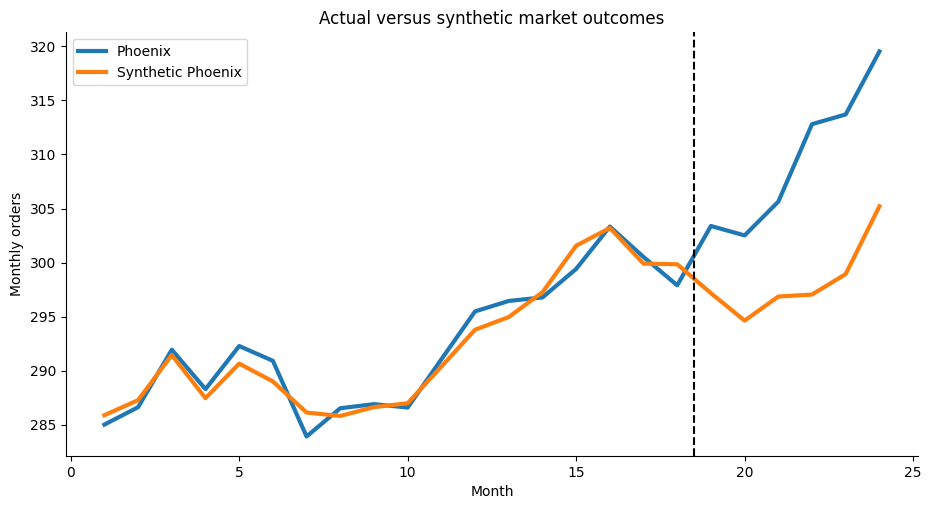

In [7]:
fig, ax = plt.subplots(figsize=(11, 5.5))
ax.plot(outcome_wide.index, outcome_wide[treated_market], linewidth=3, color="tab:blue", label=treated_market)
ax.plot(synthetic_series.index, synthetic_series, linewidth=3, color="tab:orange", label=f"Synthetic {treated_market}")
ax.axvline(treatment_start - 0.5, color="black", linestyle="--", linewidth=1.5)
ax.set_title("Actual versus synthetic market outcomes")
ax.set_xlabel("Month")
ax.set_ylabel("Monthly orders")
ax.yaxis.set_major_formatter(StrMethodFormatter("{x:,.0f}"))
ax.legend(frameon=True)
plt.show()

## 5. Estimate The Treatment Effect As A Gap

The synthetic control estimate is the difference between the treated unit and its synthetic counterpart after treatment begins.

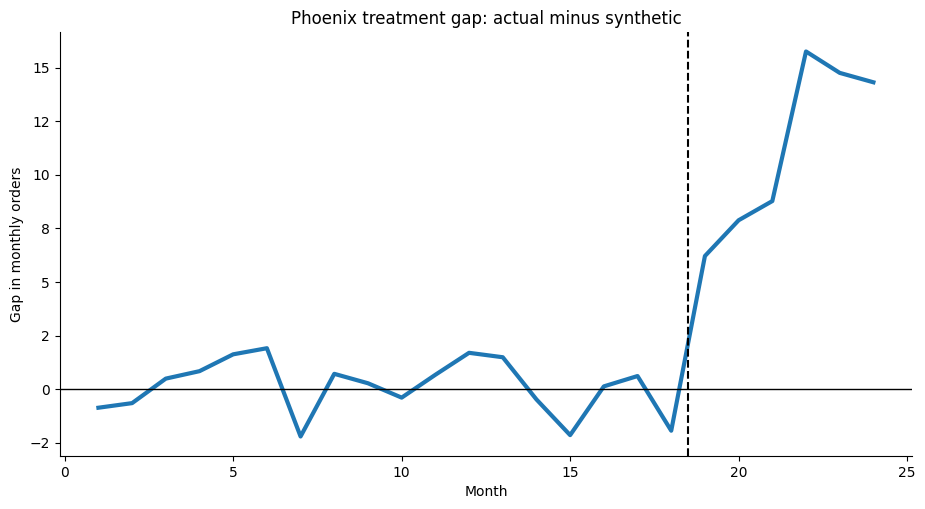

In [8]:
fig, ax = plt.subplots(figsize=(11, 5.5))
ax.plot(treated_gap.index, treated_gap, linewidth=3, color="tab:blue")
ax.axhline(0, color="black", linewidth=1)
ax.axvline(treatment_start - 0.5, color="black", linestyle="--", linewidth=1.5)
ax.set_title("Phoenix treatment gap: actual minus synthetic")
ax.set_xlabel("Month")
ax.set_ylabel("Gap in monthly orders")
ax.yaxis.set_major_formatter(StrMethodFormatter("{x:,.0f}"))
plt.show()

In [9]:
print(f"Pre-treatment RMSPE: {treated_pre_rmspe:.2f}")
print(f"Post-treatment RMSPE: {treated_post_rmspe:.2f}")
print(f"Post/Pre RMSPE ratio: {treated_post_rmspe / treated_pre_rmspe:.2f}")

Pre-treatment RMSPE: 1.26
Post-treatment RMSPE: 11.89
Post/Pre RMSPE ratio: 9.44


## 6. Placebo Tests

A standard synthetic control diagnostic is the placebo test. Pretend each donor market was treated in month 19, fit a synthetic control for it using the other donor markets, and compare the resulting placebo gaps to Phoenix's gap.

If Phoenix shows a much larger post-treatment divergence than the placebo markets, that strengthens the case that the pilot mattered.

In [10]:
gap_df = pd.DataFrame(index=outcome_wide.index)
gap_df[treated_market] = treated_gap

placebo_rows = []
for placebo_market in donor_markets:
    placebo_pool = [market for market in donor_markets if market != placebo_market]
    _, _, placebo_gap, placebo_pre_rmspe, placebo_post_rmspe = fit_scm_weights(
        target_unit=placebo_market,
        donor_pool=placebo_pool,
        predictor_data=predictor_df,
        outcome_data=outcome_wide[donor_markets],
        features=fit_features,
    )
    gap_df[placebo_market] = placebo_gap
    placebo_rows.append(
        {
            "market_id": placebo_market,
            "pre_rmspe": placebo_pre_rmspe,
            "post_rmspe": placebo_post_rmspe,
            "ratio": placebo_post_rmspe / placebo_pre_rmspe,
        }
    )

placebo_summary = pd.DataFrame(placebo_rows)
placebo_summary.head()

,market_id,pre_rmspe,post_rmspe,ratio
0,Austin,2.591,2.600,1.003
1,Charlotte,2.911,3.194,1.097
2,Columbus,2.531,3.383,1.337
3,Denver,3.093,3.650,1.180
4,Indianapolis,9.926,11.540,1.163


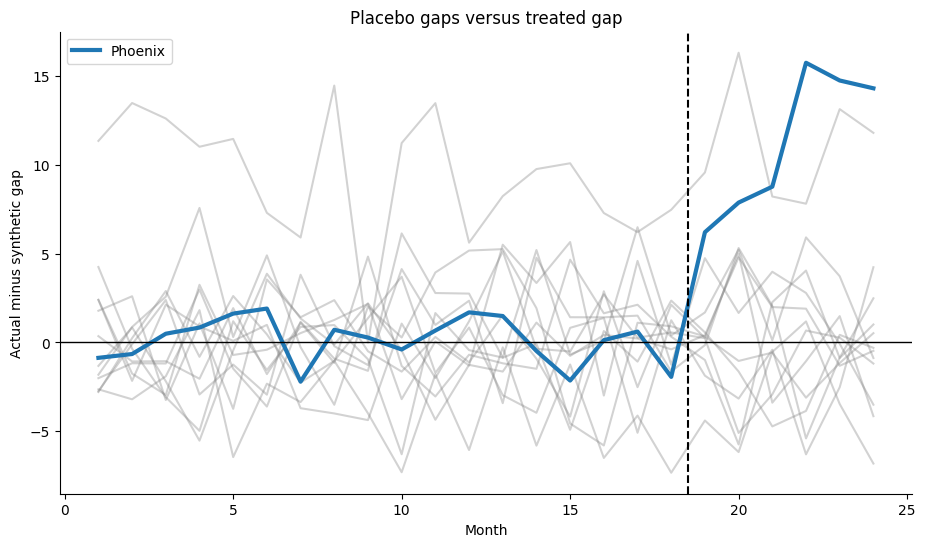

In [11]:
fig, ax = plt.subplots(figsize=(11, 6))
for placebo_market in donor_markets:
    ax.plot(gap_df.index, gap_df[placebo_market], color="gray", alpha=0.35, linewidth=1.5)

ax.plot(gap_df.index, gap_df[treated_market], color="tab:blue", linewidth=3, label=treated_market)
ax.axhline(0, color="black", linewidth=1)
ax.axvline(treatment_start - 0.5, color="black", linestyle="--", linewidth=1.5)
ax.set_title("Placebo gaps versus treated gap")
ax.set_xlabel("Month")
ax.set_ylabel("Actual minus synthetic gap")
ax.yaxis.set_major_formatter(StrMethodFormatter("{x:,.0f}"))
ax.legend(frameon=True)
plt.show()

In [12]:
rmspe_table = pd.concat(
    [
        pd.DataFrame(
            {
                "market_id": [treated_market],
                "pre_rmspe": [treated_pre_rmspe],
                "post_rmspe": [treated_post_rmspe],
                "ratio": [treated_post_rmspe / treated_pre_rmspe],
            }
        ),
        placebo_summary,
    ],
    ignore_index=True,
).sort_values("ratio", ascending=False)

rmspe_table.head(8).round(3)

,market_id,pre_rmspe,post_rmspe,ratio
0,Phoenix,1.260,11.894,9.443
10,Sacramento,2.403,3.601,1.498
6,KansasCity,2.155,3.093,1.435
3,Columbus,2.531,3.383,1.337
9,Portland,2.358,3.085,1.309
4,Denver,3.093,3.650,1.180
5,Indianapolis,9.926,11.540,1.163
2,Charlotte,2.911,3.194,1.097


## Takeaways

- Synthetic control is useful when one aggregate unit is treated and a donor pool remains untreated.
- The shock here is the month-19 loyalty-app launch in Phoenix.
- Identification depends on good pre-treatment fit, no spillovers, and no other Phoenix-only shock at the intervention date.
- Predictor balance and the pre-treatment trajectory show whether the synthetic control is a credible counterfactual.
- Placebo gaps and RMSPE ratios help assess whether the Phoenix post-treatment gap is unusually large relative to untreated markets.

In [13]:
summary = pd.Series({
    "Treated market": treated_market,
    "Treatment start month": treatment_start,
    "Donor markets": len(donor_markets),
    "Pre RMSPE": round(treated_pre_rmspe, 2),
    "Post RMSPE": round(treated_post_rmspe, 2),
    "RMSPE ratio": round(treated_post_rmspe / treated_pre_rmspe, 2),
})
summary

Treated market           Phoenix
Treatment start month         19
Donor markets                 12
Pre RMSPE                  1.260
Post RMSPE                11.890
RMSPE ratio                9.440
dtype: object